# Toy Example of S-phase Copy Number Replication Normalization

May 24, 2024

## Goal:
Create a procedure to make clear the copy number correction process

## Inputs:
- Raw gene expression reads
- Replication timing profile (deconvolved time, more granular than the experiment)
- H matrix with information on how much of each cell has progressed through the cell cycle.



In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


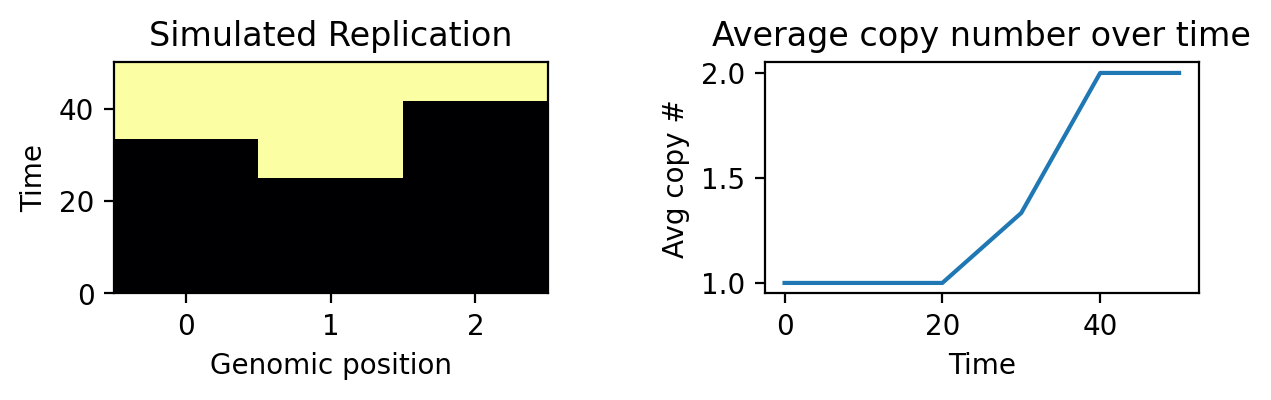

In [132]:
from src.ToyReplication import ToyReplication

# Let's create a replication profile with the dimensions of H
from src.delta_config import load_yl_delta_config
from src.helpers import calcH

length_timecourse = 60
step_min = 10 # Progress time by 10 minutes

# Deconvolution timepoints for fine grained replication timing
deconv_tps = np.arange(0, length_timecourse, 10)

# Experimental timepoints for the observed data later on
tps = np.arange(0, length_timecourse, step_min)

# One origin that fires at 25 bp at 10 min
n = 3 # 2 genomic positions
origins = { 30: [1] }

# Replication profile 
toy_repl_example = ToyReplication(n=n, timepoints=deconv_tps, origins=origins)
toy_repl_example.replicate()
toy_repl_example.replication_matrix = np.array(
      [[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 2, 1],
       [2, 2, 1],
       [2, 2, 2]])

toy_repl_example.plot_replication()

In [189]:
# Create a replication profile from an H, mixture of S
# Decide on which deconvolved timepoints replication will occur for the 
# three positions in the genome

# Early, Mid, Late
experimental_times = tps
replication_indices = [100, 110, 120]

# Then for each position, we can compute a proportion of the population that has replicated
# from H

copy2_props_mat = np.zeros((len(tps), len(replication_indices)))
for i in range(len(tps)):
    time = tps[i]

    for genome_idx in range(3):
        proportion_replicated = H[i, replication_indices[genome_idx]:].sum()
        copy2_props_mat[i, genome_idx] = proportion_replicated


In [211]:
observed_reads = copy2_props_mat

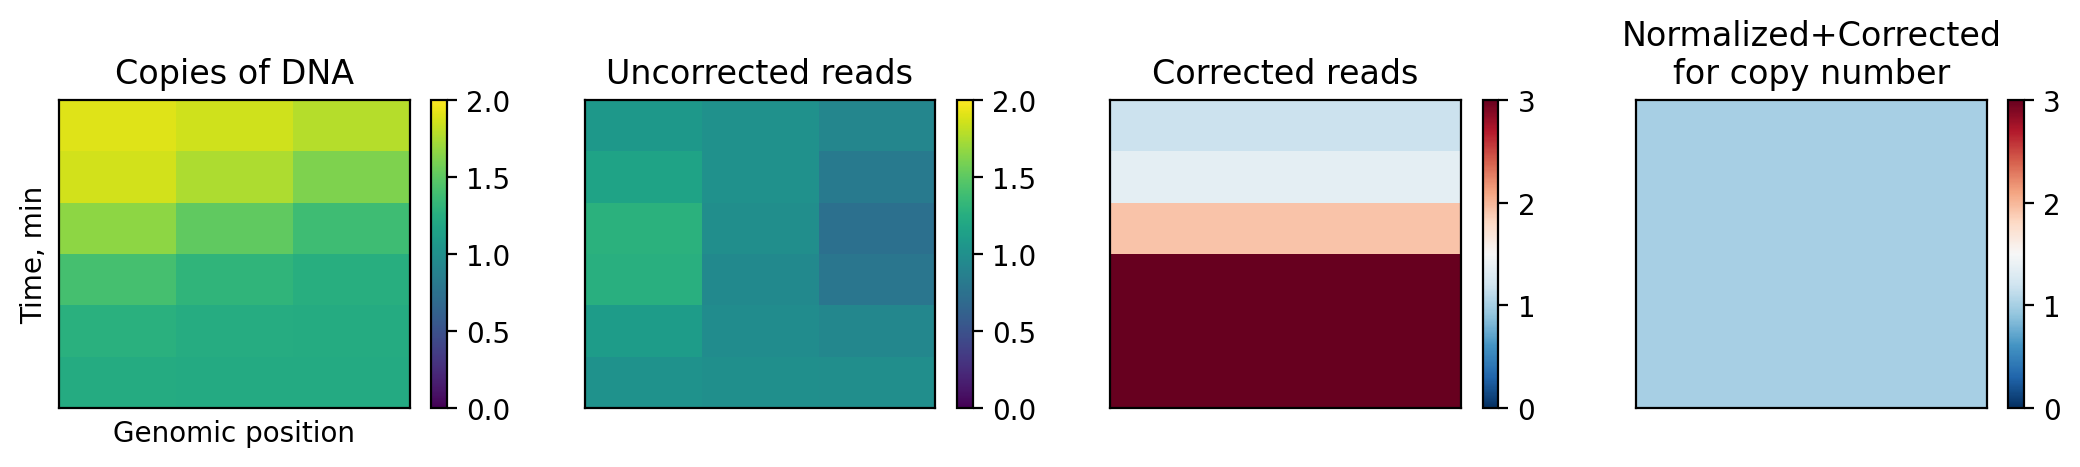

In [221]:
toy_repl_example.copy_num_2_props = copy2_props_mat
toy_repl_example.set_reads(observed_reads, tps)
toy_repl_example.copy_number_correction()
toy_repl_example.plot_correction()

Text(0.5, 1.0, 'Normalized+Corrected\nfor copy number')

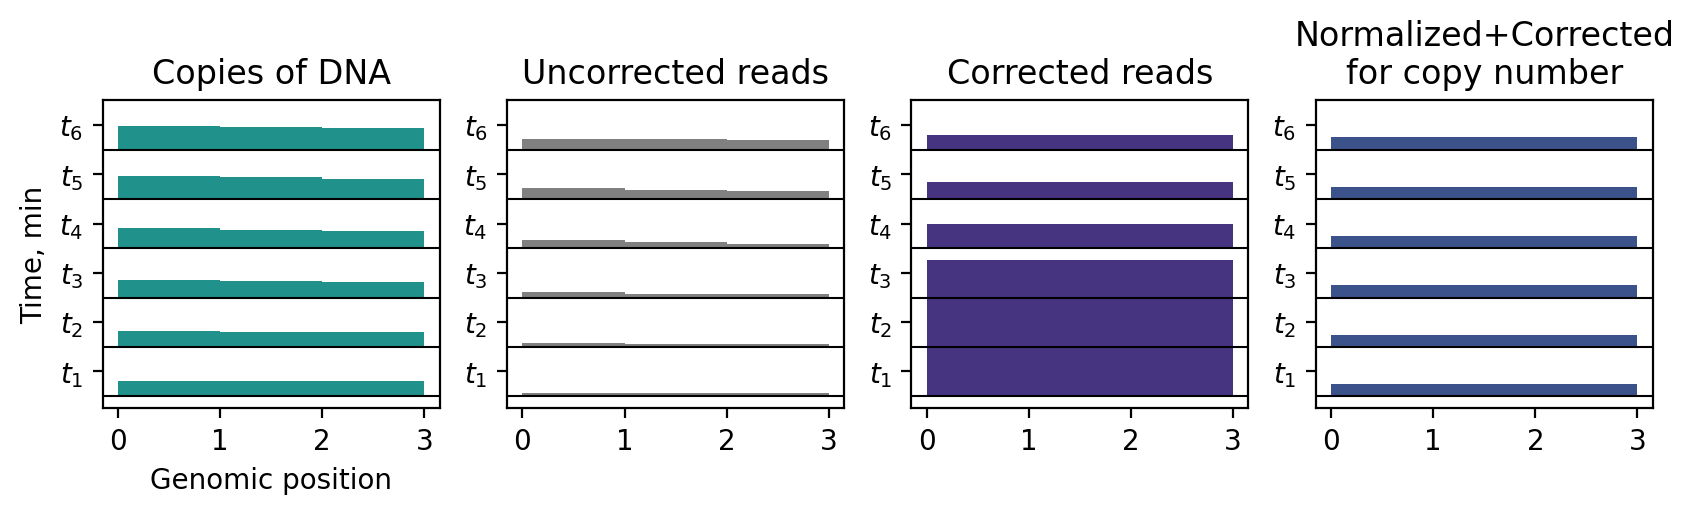

In [222]:
from src.ToyCopyNumberCorrect import plot_reads_bar
plt.figure(figsize=(10, 2))
plt.subplot(1, 4, 1)
plot_reads_bar(toy_repl_example.copy_num_2_props+1., scale=2,
              color=plt.get_cmap('viridis')(0.5))
plt.title("Copies of DNA")
plt.ylabel("Time, min")
plt.xlabel("Genomic position")
    
plt.subplot(1, 4, 2)
plot_reads_bar(toy_repl_example.reads, scale=2)
plt.title("Uncorrected reads")

plt.subplot(1, 4, 3)
plot_reads_bar(toy_repl_example.corrected_copy_num_reads, scale=2,
                color=plt.get_cmap('viridis')(0.15))
plt.title("Corrected reads")

plt.subplot(1, 4, 4)
plot_reads_bar(toy_repl_example.normalized_corrected_reads, scale=2,
                color=plt.get_cmap('viridis')(0.25))
plt.title("Normalized+Corrected\nfor copy number")

In [275]:
H, Hpos = config1.calcH_function(config1.intervals_wt1, config1.WT1_TIMEPOINTS)

Text(0.5, 1.0, 'Copy number per gene, normalized\nby overal genome replication timing')

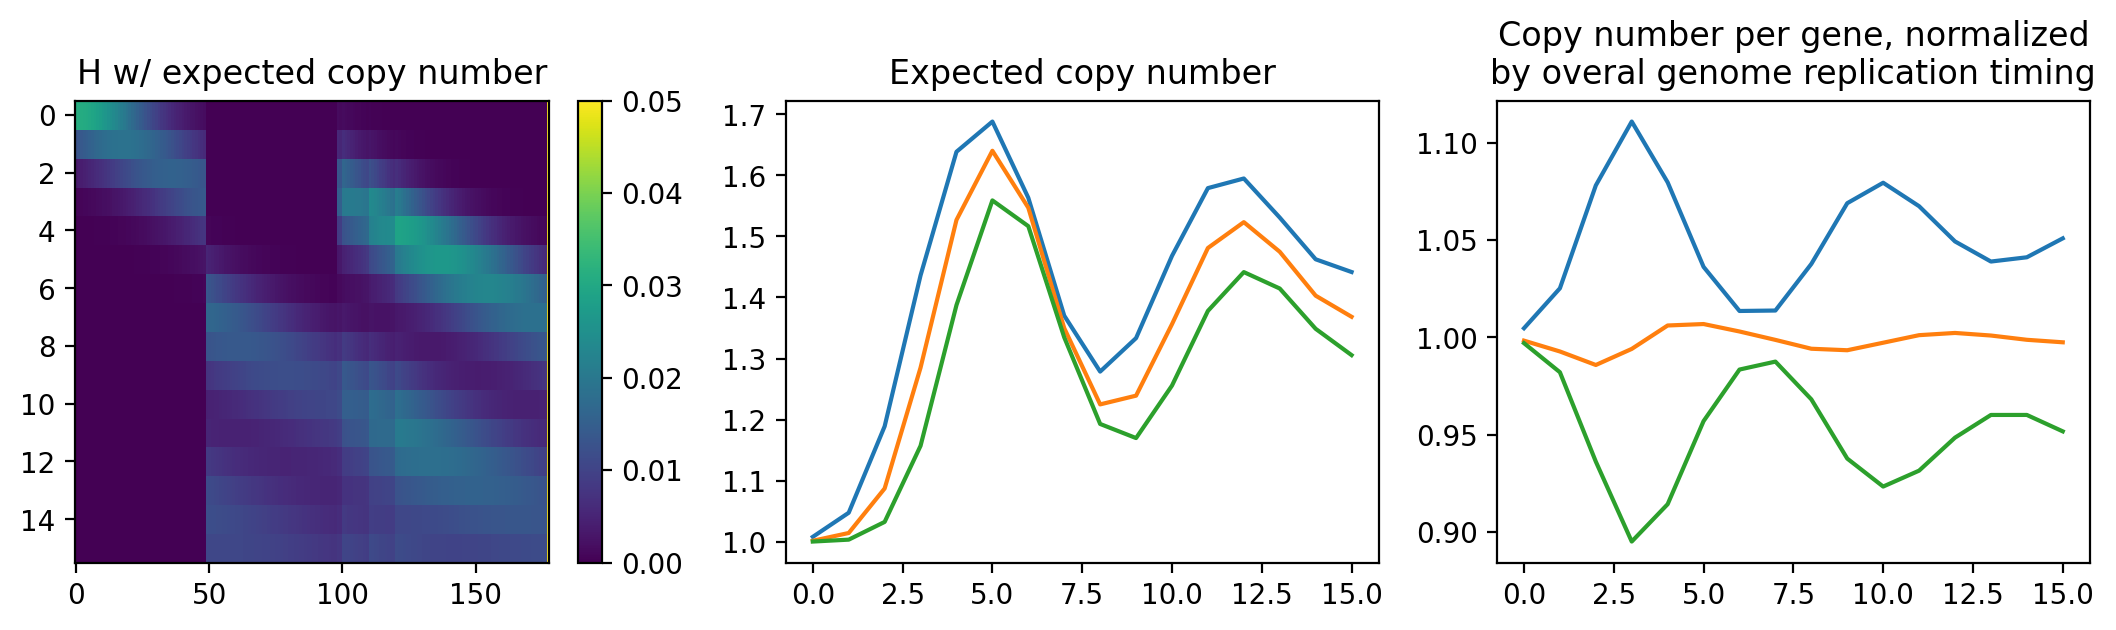

In [321]:
from src.copy_correction_reanalysis import create_copy_number_H, correct_replication_indices

(H_combined_copy_num, 
 H_expected_copy_per_gene, 
 H_normalized_copy_per_gene) = correct_replication_indices(H, replication_indices)

plt.figure(figsize=(13, 3))
plt.subplot(1, 3, 1)
plt.imshow(H_combined_copy_num, vmax=0.05, aspect='auto', interpolation='none')
plt.colorbar()
plt.title("H w/ expected copy number")

plt.subplot(1, 3, 2)
plt.plot(H_expected_copy_per_gene.sum(axis=2).T)
plt.title("Expected copy number")

plt.subplot(1, 3, 3)
plt.plot(H_normalized_copy_per_gene)
plt.title("Copy number per gene, normalized\nby overal genome replication timing")
